# Count-to-TPM normalization

**Count 转 TPM**

Convert the public STAD count matrix using packaged gene lengths; inspect library totals and expressed-gene distributions.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
counts = load("eset_stad")
input_shape = counts.shape
display(counts.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
rownames,,,,
ENSG00000000003,8006.0,2114.0,767.0,1556.0
ENSG00000000005,1.0,0.0,5.0,5.0
ENSG00000000419,3831.0,2600.0,1729.0,1760.0
ENSG00000000457,1126.0,745.0,1040.0,1260.0
ENSG00000000460,857.0,463.0,231.0,432.0


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.count2tpm(counts, idType="Ensembl", org="hsa", check_data=True, remove_version=True)
elapsed = perf_counter() - started
display(save_result(result, "02_counts_to_tpm", elapsed, input_shape))

Completed in 0.105 s; input 60,483 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,02_counts_to_tpm,0.105075,"[60483, 10]","{'result': [48058, 10]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380,TCGA-BR-8592,TCGA-BR-8686,TCGA-BR-A4IV,TCGA-BR-A4J4,TCGA-BR-A4J9,TCGA-FP-7916
MT-CO1,25097.553024,24055.972843,59199.134752,50164.981725,47776.978920,34875.457527,50009.922464,27982.230497,63380.898517,26287.974669
MT-ND4,14525.308129,14963.923341,48195.670862,32185.130734,36283.385896,31111.091726,35885.023048,49689.107679,39741.237252,14473.972195
MT-CO3,12465.198276,14835.808744,47590.766557,34559.374807,35808.709160,27071.096475,37804.385954,22623.828241,43837.584423,17801.268843
IGKC,9897.134453,78664.047321,713.537221,4372.862276,27027.240386,50262.873023,10617.201155,2900.288025,21222.089725,70074.940881
MT-CO2,12920.617435,13063.071078,33664.670548,21527.455301,25992.405542,20287.578970,32023.192116,54797.893440,30150.490406,13184.959857


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

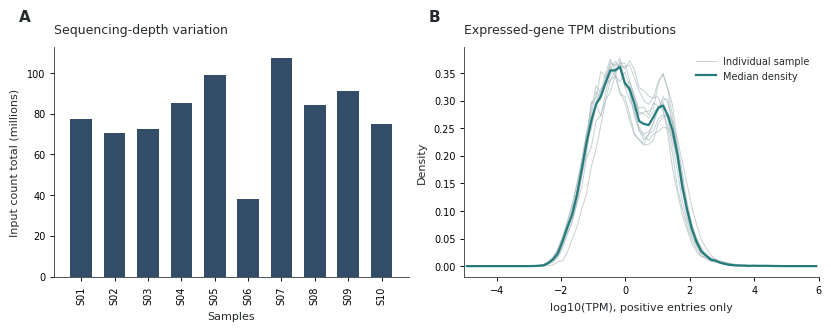

,sample,returned_TPM_sum,retained_percent_of_1e6,zero_TPM_percent
0,TCGA-BR-6455,999351.907728,99.935191,28.005743
1,TCGA-BR-7196,999349.581174,99.934958,28.927546
2,TCGA-BR-8371,998672.661411,99.867266,18.411087
3,TCGA-BR-8380,999303.191415,99.930319,22.913979
4,TCGA-BR-8592,999125.098214,99.912510,26.952849
5,TCGA-BR-8686,998588.674820,99.858867,30.465271
6,TCGA-BR-A4IV,998721.731750,99.872173,21.118232
7,TCGA-BR-A4J4,999086.163847,99.908616,21.238920
8,TCGA-BR-A4J9,999086.785226,99.908679,21.340880
9,TCGA-FP-7916,999149.216760,99.914922,19.370344


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2), layout="constrained")
sample_labels = short_samples(counts.columns)
axes[0].bar(np.arange(len(counts.columns)), counts.sum() / 1e6, color=NAVY, width=0.65)
axes[0].set_xticks(range(len(sample_labels)), sample_labels, rotation=90)
axes[0].set(xlabel="Samples", ylabel="Input count total (millions)")
densities = []
for j in range(result.shape[1]):
    positive = result.iloc[:, j].to_numpy()
    values = np.log10(positive[positive > 0])
    density, edges = np.histogram(values, bins=np.linspace(-5, 6, 75), density=True)
    densities.append(density)
    axes[1].plot((edges[:-1] + edges[1:]) / 2, density, color="#A6B8BC", linewidth=0.7, alpha=0.65, label="Individual sample" if j == 0 else None)
axes[1].plot((edges[:-1] + edges[1:]) / 2, np.median(densities, axis=0), color=TEAL, linewidth=1.6, label="Median density")
axes[1].legend(loc="upper right")
axes[1].set(xlabel="log10(TPM), positive entries only", ylabel="Density", xlim=(-5, 6))
panel(axes[0], "A", "Sequencing-depth variation")
panel(axes[1], "B", "Expressed-gene TPM distributions")
save_figure(fig, '02_counts_to_tpm')
display(pd.DataFrame({"sample": counts.columns, "returned_TPM_sum": result.sum().to_numpy(), "retained_percent_of_1e6": result.sum().to_numpy() / 10000, "zero_TPM_percent": (result == 0).mean().to_numpy() * 100}))


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

Use raw, nonnegative gene counts—not log expression or an already normalized TPM matrix. Missing lengths, feature filtering and post-normalization symbol deduplication can leave returned column sums slightly below one million. The notebook reports this explicitly instead of silently renormalizing the output.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/02_counts_to_tpm.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.